First five rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  
Training samples: 120
Testing samples: 30
Accuracy: 1.0


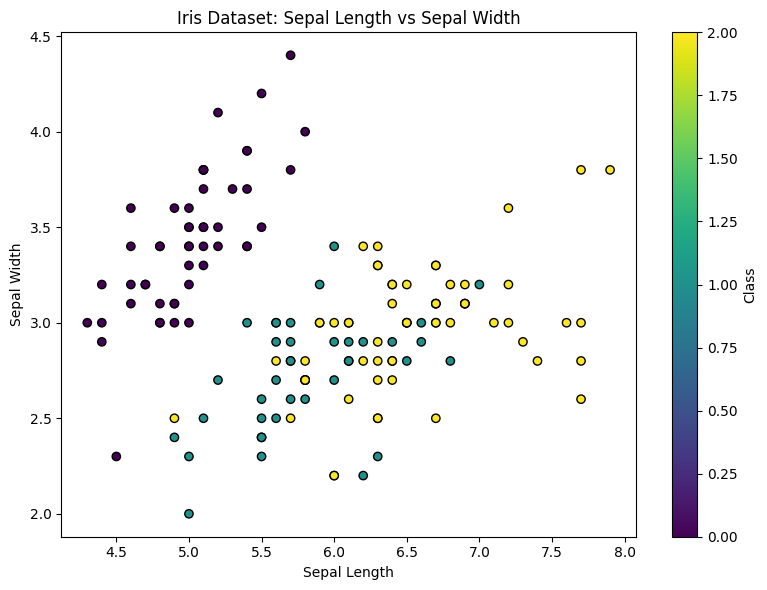

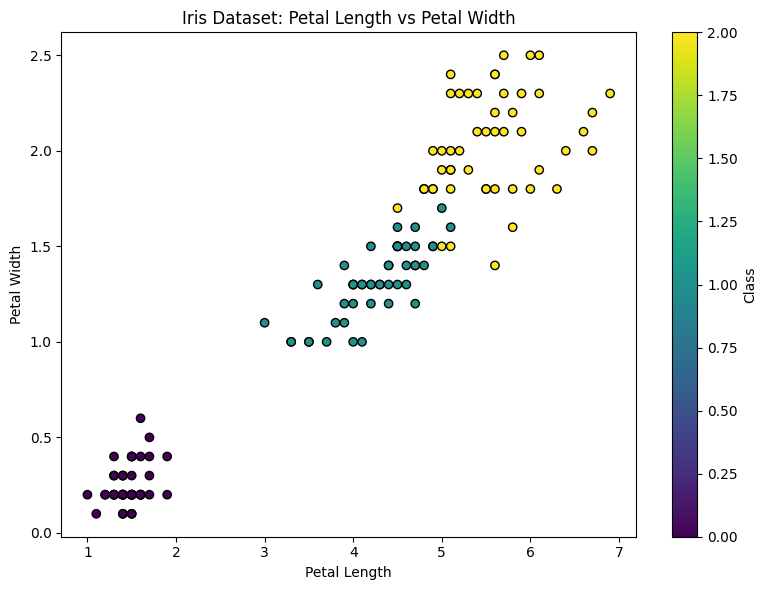

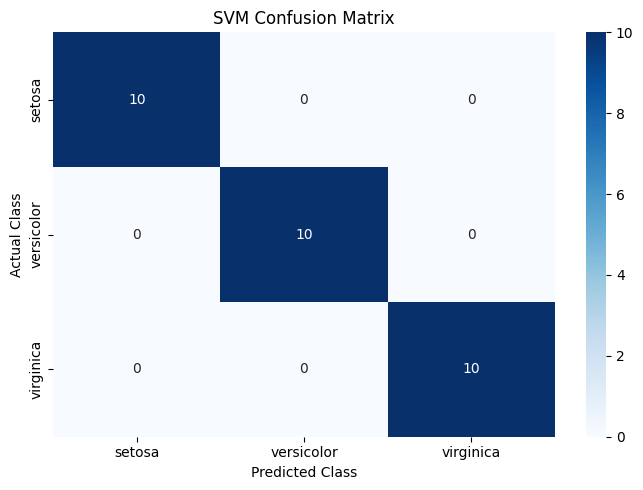

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# ==========================================

# 1. Load Iris Dataset

# ==========================================

iris = load_iris()

X = iris.data
y = iris.target

# ==========================================

# 2. Create DataFrame

# ==========================================

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["Target"] = y

print("First five rows:")
print(df.head())

# ==========================================

# 3. Split Dataset

# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ==========================================

# 4. Feature Scaling

# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================

# 5. Create SVM Model

# ==========================================

model = SVC(
    kernel="linear",
    C=1.0
)

# ==========================================

# 6. Train SVM Model

# ==========================================

model.fit(X_train_scaled, y_train)

# ==========================================

# 7. Prediction

# ==========================================

y_pred = model.predict(X_test_scaled)

# ==========================================

# 8. Accuracy

# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# ==========================================

# GRAPH 1

# Sepal Length vs Sepal Width

# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="black"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset: Sepal Length vs Sepal Width")

plt.colorbar(
    label="Class"
)

plt.tight_layout()

plt.savefig(
    "sepal_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================

# GRAPH 2

# Petal Length vs Petal Width

# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 2],
    X[:, 3],
    c=y,
    cmap="viridis",
    edgecolor="black"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset: Petal Length vs Petal Width")

plt.colorbar(
    label="Class"
)

plt.tight_layout()

plt.savefig(
    "petal_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================

# GRAPH 3

# Confusion Matrix

# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SVM Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()